# Import and Install

In [1]:
# !pip install fastparquet imbalanced-learn matplotlib seaborn pyarrow xgboost lightgbm catboost scikit-learn==1.8.0 cleanlab

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

import joblib

In [3]:
FEATURE_COLUMNS = [
    "Flow Duration", "Total Fwd Packets", "Total Backward Packets",
    "Total Length of Fwd Packets", "Total Length of Bwd Packets",
    "Fwd Packet Length Std", "Bwd Packet Length Min", "Bwd Packet Length Std",
    "Flow IAT Min", "Fwd IAT Total", "Fwd IAT Min", "Fwd PSH Flags",
    "Fwd Header Length", "Fwd Packets/s", "SYN Flag Count", "ACK Flag Count",
    "URG Flag Count", "CWE Flag Count", "Init_Win_bytes_forward",
    "act_data_pkt_fwd", "min_seg_size_forward", "Active Mean", "Idle Mean",
]

COLUMN_RENAME_MAP = {
    "flow_duration": "Flow Duration", "tot_fwd_pkts": "Total Fwd Packets",
    "tot_bwd_pkts": "Total Backward Packets", "totlen_fwd_pkts": "Total Length of Fwd Packets",
    "totlen_bwd_pkts": "Total Length of Bwd Packets", "fwd_pkt_len_std": "Fwd Packet Length Std",
    "bwd_pkt_len_min": "Bwd Packet Length Min", "bwd_pkt_len_std": "Bwd Packet Length Std",
    "flow_iat_min": "Flow IAT Min", "fwd_iat_tot": "Fwd IAT Total",
    "fwd_iat_min": "Fwd IAT Min", "fwd_psh_flags": "Fwd PSH Flags",
    "fwd_header_len": "Fwd Header Length", "fwd_pkts_s": "Fwd Packets/s",
    "syn_flag_cnt": "SYN Flag Count", "ack_flag_cnt": "ACK Flag Count",
    "urg_flag_cnt": "URG Flag Count", "cwr_flag_count": "CWE Flag Count",
    "init_fwd_win_byts": "Init_Win_bytes_forward", "fwd_act_data_pkts": "act_data_pkt_fwd",
    "fwd_seg_size_min": "min_seg_size_forward", "active_mean": "Active Mean",
    "idle_mean": "Idle Mean",
}

# Labeler

In [4]:
# โหลดข้อมูลไฟล์ CSV
df = pd.read_csv(r'dataset\flow_logs.csv')

# แสดงข้อมูล 5 แถวแรกเพื่อตรวจสอบ
display(df.head())

,src_ip,dst_ip,src_port,dst_port,protocol,timestamp,flow_duration,flow_byts_s,flow_pkts_s,fwd_pkts_s,...,bwd_pkts_b_avg,fwd_blk_rate_avg,bwd_blk_rate_avg,fwd_seg_size_avg,bwd_seg_size_avg,cwr_flag_count,subflow_fwd_pkts,subflow_bwd_pkts,subflow_fwd_byts,subflow_bwd_byts
0,142.250.66.106,10.10.188.89,443,52326,6,2026-02-22 16:24:31,1.973969,222465.981385,309.022042,164.136298,...,284.0,0.000000,1.833462e+06,77.361111,1447.818182,0,324,286,25065,414076
1,10.200.12.52,10.10.188.89,64735,22,6,2026-02-22 16:24:31,3.715423,7749.857599,79.937060,40.372253,...,5.0,0.000000,4.970639e+05,88.000000,106.081633,0,150,147,13200,15594
2,10.200.12.52,10.10.188.89,64735,22,6,2026-02-22 16:25:32,3.085369,8227.865469,85.565134,46.023670,...,6.0,3187.071398,4.840842e+05,84.830986,109.344262,0,142,122,12046,13340
3,142.250.66.106,10.10.188.89,443,52326,6,2026-02-22 16:26:31,0.040328,4909.736988,74.389954,49.593303,...,0.0,0.000000,0.000000e+00,66.000000,66.000000,0,2,1,132,66
4,10.200.12.52,10.10.188.89,64735,22,6,2026-02-22 16:27:09,10.210399,8772.428637,96.078514,49.361438,...,6.5,8039.609854,2.927785e+05,88.587302,94.176101,0,504,477,44648,44922


In [5]:
def auto_labeler_with_baseline(new_df):
    try:
        # 1. โหลดโมเดลและรายชื่อ Feature ที่เคยใช้ตอน Fit
        gmm = joblib.load('model/baseline_gmm_model.joblib')
        scaler = joblib.load('model/baseline_scaler.joblib')
        threshold = joblib.load('model/baseline_threshold.joblib')
        saved_features = joblib.load('model/baseline_features_list.joblib') # เช่น ['flow_duration', ...]
        
        # 2. สร้าง Mapping เพื่อหาว่าชื่อเก่าคู่กับชื่อใหม่คืออะไร
        mapping = {
            'flow_duration': 'Flow Duration',
            'tot_fwd_pkts': 'Total Fwd Packets',
            'flow_pkts_s': 'Flow Packets/s',
            'fwd_pkts_s': 'Fwd Packets/s'
        }
        
        # 3. สร้าง DataFrame ใหม่ที่มีชื่อคอลัมน์ "ตรงเป๊ะ" กับตอนที่ Fit โมเดล
        X_input = pd.DataFrame()
        for f in saved_features:
            if f in new_df.columns:
                X_input[f] = new_df[f]
            elif mapping.get(f) in new_df.columns:
                # ถ้าเจอชื่อ 'Flow Duration' ให้เอามาใส่ในคอลัมน์ชื่อ 'flow_duration'
                X_input[f] = new_df[mapping[f]]
            else:
                raise KeyError(f"ไม่พบข้อมูลคอลัมน์ {f} หรือ {mapping.get(f)}")

        # 4. ตอนนี้ X_input จะมีชื่อคอลัมน์เป็นตัวเล็กตามที่โมเดลต้องการแล้ว
        X_new_scaled = scaler.transform(X_input)
        
        # 5. คำนวณคะแนน
        new_scores = gmm.score_samples(X_new_scaled)
        
        # 6. ตัดสิน Label (0 = Normal, 1 = Attack)
        # buffer -10 เพื่อให้โมเดลยืดหยุ่นกับ Spike ที่อาจจะแรงกว่าเดิมนิดหน่อย
        labels = np.where(new_scores >= (threshold - 10), 0, 1)
        return labels

    except Exception as e:
        print(f"Error: {e}")
        return np.full(len(new_df), -1)

# เรียกใช้งาน
df['Label'] = auto_labeler_with_baseline(df)
print(df['Label'].value_counts())

df.rename(columns=COLUMN_RENAME_MAP, inplace=True)
display(df.head())


Label
0    5866
Name: count, dtype: int64


,src_ip,dst_ip,src_port,dst_port,protocol,timestamp,Flow Duration,flow_byts_s,flow_pkts_s,Fwd Packets/s,...,fwd_blk_rate_avg,bwd_blk_rate_avg,fwd_seg_size_avg,bwd_seg_size_avg,CWE Flag Count,subflow_fwd_pkts,subflow_bwd_pkts,subflow_fwd_byts,subflow_bwd_byts,Label
0,142.250.66.106,10.10.188.89,443,52326,6,2026-02-22 16:24:31,1.973969,222465.981385,309.022042,164.136298,...,0.000000,1.833462e+06,77.361111,1447.818182,0,324,286,25065,414076,0
1,10.200.12.52,10.10.188.89,64735,22,6,2026-02-22 16:24:31,3.715423,7749.857599,79.937060,40.372253,...,0.000000,4.970639e+05,88.000000,106.081633,0,150,147,13200,15594,0
2,10.200.12.52,10.10.188.89,64735,22,6,2026-02-22 16:25:32,3.085369,8227.865469,85.565134,46.023670,...,3187.071398,4.840842e+05,84.830986,109.344262,0,142,122,12046,13340,0
3,142.250.66.106,10.10.188.89,443,52326,6,2026-02-22 16:26:31,0.040328,4909.736988,74.389954,49.593303,...,0.000000,0.000000e+00,66.000000,66.000000,0,2,1,132,66,0
4,10.200.12.52,10.10.188.89,64735,22,6,2026-02-22 16:27:09,10.210399,8772.428637,96.078514,49.361438,...,8039.609854,2.927785e+05,88.587302,94.176101,0,504,477,44648,44922,0


In [6]:
# บันทึกเป็นไฟล์ CSV ตัวใหม่ (ไม่ต้องเซฟ index)
df.to_csv(r'dataset\labeled_flow_logs.csv', index=False)

# Add Attack to dataset

In [7]:
path_labeled = r'dataset\labeled_flow_logs.csv'
df_new = pd.read_csv(path_labeled   )
print('Data Shape:', df_new.shape)
print(df_new.head())
print(df_new.info())

Data Shape: (5866, 83)
           src_ip        dst_ip  src_port  dst_port  protocol  \
0  142.250.66.106  10.10.188.89       443     52326         6   
1    10.200.12.52  10.10.188.89     64735        22         6   
2    10.200.12.52  10.10.188.89     64735        22         6   
3  142.250.66.106  10.10.188.89       443     52326         6   
4    10.200.12.52  10.10.188.89     64735        22         6   

             timestamp  Flow Duration    flow_byts_s  flow_pkts_s  \
0  2026-02-22 16:24:31       1.973969  222465.981385   309.022042   
1  2026-02-22 16:24:31       3.715423    7749.857599    79.937060   
2  2026-02-22 16:25:32       3.085369    8227.865469    85.565134   
3  2026-02-22 16:26:31       0.040328    4909.736988    74.389954   
4  2026-02-22 16:27:09      10.210399    8772.428637    96.078514   

   Fwd Packets/s  ...  fwd_blk_rate_avg  bwd_blk_rate_avg  fwd_seg_size_avg  \
0     164.136298  ...          0.000000      1.833462e+06         77.361111   
1      40.372

In [ ]:
missing_cols = [col for col in FEATURE_COLUMNS if col not in df_new.columns]
if missing_cols:
    raise ValueError(f"Missing columns in new data: {missing_cols}")

df_new = df_new[FEATURE_COLUMNS + ["Label"]].copy()

# นับจำนวน Normal เพื่อเอาไปเป็นเกณฑ์ตั้งต้น
num_normal = len(df_new[df_new["Label"] == 0])
print(f"Normal count in new data: {num_normal}")

# คำนวณจำนวน Attack ที่ต้องการดึงมา (อย่างละครึ่งหนึ่งของ Normal)
# ถ้าอยากให้แต่ละตัวเท่ากับ Normal เลย ให้เปลี่ยน 0.5 เป็น 1.0 ครับ
target_sample_size = int(num_normal * 0.5) 
print(f"Target attack sample size (per source): {target_sample_size}")

# 2. โหลด Dataset เก่า (featured_train) 
df_old = pd.read_parquet(r'dataset\featured_train.parquet')
df_old_attack = df_old[df_old['Label'] == 1].copy()
print("Old attack count (Total):", len(df_old_attack))

# สุ่ม Attack เก่ามาเท่ากับ target_sample_size
# เช็คเผื่อกรณีที่ข้อมูลเก่ามีน้อยกว่าที่ต้องการ
actual_old_size = min(len(df_old_attack), target_sample_size)
df_old_attack_sampled = df_old_attack.sample(n=actual_old_size, random_state=42)
df_old_attack_sampled = df_old_attack_sampled[FEATURE_COLUMNS + ["Label"]]
print("Sampled old attack:", len(df_old_attack_sampled))

# 3. โหลด Dataset สังเคราะห์จาก DDoSFlowGen
path_ddos = r'ddosflowgen\dataset\ddos_flow_gen_output.csv' 
df_ddos = pd.read_csv(path_ddos)

# จัดการคอลัมน์ของ DDoS (อย่าลืมเปิดใช้ rename ถ้าชื่อคอลัมน์ไม่ตรง)
# df_ddos.rename(columns=COLUMN_RENAME_MAP, inplace=True)
df_ddos = df_ddos[FEATURE_COLUMNS].copy()
df_ddos["Label"] = 1

# สุ่ม Attack จาก DDoS มาเท่ากับ target_sample_size
actual_ddos_size = min(len(df_ddos), target_sample_size)
df_ddos_sampled = df_ddos.sample(n=actual_ddos_size, random_state=42)
print("Sampled DDoSFlowGen attack:", len(df_ddos_sampled))

# 4. รวมร่างข้อมูล
df_combined = pd.concat([df_new, df_old_attack_sampled, df_ddos_sampled], ignore_index=True)

# จัดการ Label
if df_combined["Label"].dtype == "object":
    df_combined["Label"] = df_combined["Label"].astype(str).str.strip()
    df_combined["Label"] = df_combined["Label"].map({"Normal": 0, "Attack": 1})
    
df = df_combined.copy()

print("-" * 30)
print("Data Combination Done ✔")
print("Total Shape:", df.shape)
print("Label Distribution:\n", df["Label"].value_counts())

Normal count in new data: 5866
Target attack sample size (per source): 2933
Old attack count (Total): 8291743
Sampled old attack: 2933
Sampled DDoSFlowGen attack: 575
------------------------------
Data Combination Done ✔
Total Shape: (9374, 24)
Label Distribution:
 Label
0    5866
1    3508
Name: count, dtype: int64


# Data Cleaning

In [9]:
has_inf = np.isinf(df.select_dtypes(include=np.number)).any().any()
print(f"Contains inf rows?: {has_inf}")
if has_inf:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    numeric_cols = df.select_dtypes(include=np.number).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    print("Replaced inf with median.")

has_nan = df.isnull().values.any()
if has_nan:
    numeric_cols = df.select_dtypes(include=np.number).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    print(f"Filled NaN values.")

has_dup = df.duplicated().any()
print(f"Contains duplicate rows?: {has_dup}")
if has_dup:
    count_dup = df.duplicated().sum()
    print(f"Found {count_dup} duplicate rows. Dropping...")
    df.drop_duplicates(inplace=True)
    
df.reset_index(drop=True, inplace=True)
print("Data cleaning complete and index reset.")

Contains inf rows?: False
Contains duplicate rows?: True
Found 931 duplicate rows. Dropping...
Data cleaning complete and index reset.


Data scaled successfully using the first model's scaler.


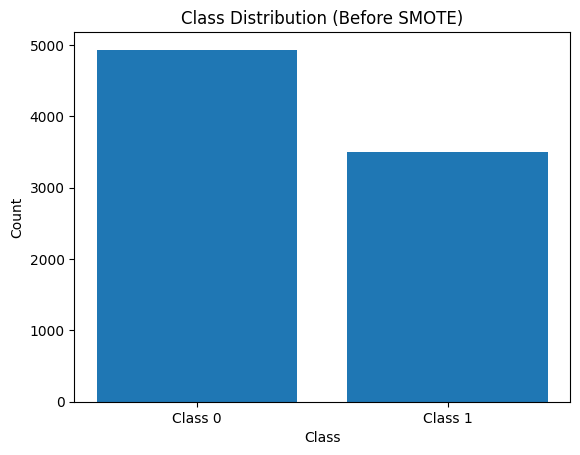

Applying SMOTE...
After SMOTE:
 Label
0    4936
1    4936
Name: count, dtype: int64


In [10]:
non_nan_labels_mask = df["Label"].notna()
df_for_smote = df[non_nan_labels_mask].copy()

# แยก Features (X) และ Label (y)
X = df_for_smote[FEATURE_COLUMNS]
y = df_for_smote["Label"]

# 2. นำ Scaler "ตัวที่ใช้เทรนโมเดลหลักในรอบแรก" มาใช้
main_scaler = joblib.load('model/scaler.joblib')
X_scaled_array = main_scaler.transform(X)

# แปลงกลับเป็น DataFrame เพื่อให้เอาไปใช้กับ SMOTE ได้ง่ายและคงชื่อคอลัมน์ไว้
X_scaled = pd.DataFrame(X_scaled_array, columns=FEATURE_COLUMNS)
print("Data scaled successfully using the first model's scaler.")

# 3. พล็อตดูกราฟการกระจายตัวก่อนทำ SMOTE
count_class = y.value_counts()
plt.bar(count_class.index, count_class.values)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution (Before SMOTE)')
plt.xticks(count_class.index, [f'Class {i}' for i in count_class.index])
plt.show()

# 4. ทำ SMOTE ด้วยข้อมูลที่ถูก Scale ด้วยมาตรฐานเดิมแล้ว
print("Applying SMOTE...")
smote = SMOTE(sampling_strategy='not majority', random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

print("After SMOTE:\n", y_res.value_counts())

In [11]:
df_resampled = pd.DataFrame(X_res, columns=df_for_smote.columns)
df_resampled['Label'] = y_res

print('Shape of resampled DataFrame:', df_resampled.shape)
print(df_resampled.head())

output_path = r'dataset\resampled_flow_logs_labeled.csv'
df_resampled.to_csv(output_path, index=False)
print(f"Resampled data exported to '{output_path}'")

Shape of resampled DataFrame: (9872, 24)
   Flow Duration  Total Fwd Packets  Total Backward Packets  \
0   1.644974e-08           0.003225                0.062147   
1   3.096186e-08           0.001488                0.031943   
2   2.571141e-08           0.001408                0.026510   
3   3.360669e-10           0.000010                0.000217   
4   8.508666e-08           0.005023                0.103651   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                     0.001642                     0.037665   
1                     0.000865                     0.001418   
2                     0.000789                     0.001213   
3                     0.000009                     0.000006   
4                     0.002925                     0.004086   

   Fwd Packet Length Std  Bwd Packet Length Min  Bwd Packet Length Std  \
0               0.055630               0.045205               0.019170   
1               0.005234               0.061644      

# CSV to parquet

In [12]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq


# Paths for CSV and Parquet for the current fileName
csv_path = r'dataset\resampled_flow_logs_labeled.csv'
parquet_path = r'dataset\parquet\flow_logs.parquet'
chunk_size = 100000  # อ่านทีละ 1 แสนแถว (ปรับตาม RAM)

# 2. เริ่มกระบวนการแปลง
parquet_schema = None
writer = None

# อ่าน CSV ทีละส่วน
for i, chunk in enumerate(pd.read_csv(csv_path, chunksize=chunk_size)):

    # แปลง Pandas Chunk เป็น PyArrow Table
    table = pa.Table.from_pandas(chunk)

    # ถ้าเป็นรอบแรก (i=0) ให้สร้างไฟล์และจำ Schema
    if i == 0:
        parquet_schema = table.schema
        writer = pq.ParquetWriter(parquet_path, parquet_schema, compression='snappy')

    # เขียนข้อมูลต่อท้ายลงไฟล์เดิม
    writer.write_table(table)

# 3. ปิดไฟล์เมื่อเสร็จ (สำคัญมาก ไม่งั้นไฟล์จะเสีย)
if writer:
    writer.close()

print("Complete!")

Complete!


# Verify the consistency of the columns in all cleaned datasets.


In [13]:
import pyarrow.parquet as pq
import glob
import os

def check_parquet_schema(folder_path):
    files = glob.glob(os.path.join(folder_path, "*.parquet"))

    if not files:
        print("No Parquet files found in this folder.")
        return

    print(f"Found {len(files)} files. Starting verification...\n")

    first_file = files[0]
    try:
        ref_schema = pq.read_schema(first_file)
        print(f"Reference file: {os.path.basename(first_file)}")
        print(f"   - Total Columns: {len(ref_schema.names)}")
    except Exception as e:
        print(f"Error reading the first file: {e}")
        return

    mismatch_files = []

    for f in files[1:]:
        filename = os.path.basename(f)
        try:
            current_schema = pq.read_schema(f)

            if not ref_schema.equals(current_schema):
                print(f"Mismatch found: {filename}")

                ref_cols = set(ref_schema.names)
                cur_cols = set(current_schema.names)

                missing = ref_cols - cur_cols
                extra = cur_cols - ref_cols

                if missing: print(f"    - Missing columns: {missing}")
                if extra: print(f"    - Extra columns: {extra}")
                if not missing and not extra: print(f"    - Column names match, but order or data types differ.")

                mismatch_files.append(filename)

        except Exception as e:
            print(f"Error reading file {filename}: {e}")

    print("\n" + "="*30)
    if not mismatch_files:
        print("All files have matching structures (Index & Columns).")
    else:
        print(f"Found {len(mismatch_files)} problematic files.")

folder_path = r'dataset\parquet'
print("\n" + "="*30)
print("       TESTING FOLDER\n")
check_parquet_schema(folder_path)


       TESTING FOLDER

Found 1 files. Starting verification...

Reference file: flow_logs.parquet
   - Total Columns: 24

All files have matching structures (Index & Columns).
